# SFT Results Visualization

In [487]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from adjustText import adjust_text

# Configure matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

In [488]:
model = 'Llama-3.2-1B'
train_dataset = 'alpaca'  # Options: alpaca, tulu3, less
task = 'samsum'          # Options: samsum, tydiqa, mmlu_sociology, bbh_navigate
subject = ''           # Only needed for mmlu/bbh tasks
out_dir = "/scratch/pbb/Project/Gradient-Streaming/SFT"
lr_config_path = "/home/pbb/Project/Gradient-Streaming/SFT/train/lr/config.json"  # Path to LR configuration

# Configuration used for experiments
# See SFT/README.md for recommended parameters per dataset
default_config = {
    'batch_size': 8,
    'percentage': 0.4,   # alpaca: 0.4, tulu3: 0.01, less: 0.05
    'n_val': 32,
    'seed': 42,
    # Learning rates are now loaded from config.json per experiment
    # Fallback values used only if config lookup fails
    'lr_full_fallback': '5e-05',
    'lr_lora_fallback': '2e-04',
}

# Load LR configuration
lr_config = {}
if Path(lr_config_path).exists():
    with open(lr_config_path, 'r') as f:
        lr_config = json.load(f)
    print(f"Loaded LR config from {lr_config_path}")
else:
    print(f"Warning: LR config not found at {lr_config_path}, using fallback LRs")

# ============================================
# Plot Filtering Options
# ============================================
show_per_layer = True          # Set to True to include Per-layer (Streaming) selection methods
show_lora = True               # Set to True to include LoRA methods

Loaded LR config from /home/pbb/Project/Gradient-Streaming/SFT/train/lr/config.json


In [489]:
method_definitions = {
    # ============================================
    # 1. Baselines (NA-NA): no selection, no compression
    # ============================================
    'NA-NA-Full': ('NA', 'NA', 'Full', False),
    'NA-NA-LoRA': ('NA', 'NA', 'LoRA', False),

    # ============================================
    # 2. Streaming without compression (Streaming-NA)
    #    Per-layer selection, full gradients, standard optimizer
    #    Second-order enabled by default
    # ============================================
    'Streaming-NA-Full': ('Streaming', 'NA', 'Full', False),
    'Streaming-NA-LoRA': ('Streaming', 'NA', 'LoRA', False),

    # ============================================
    # 3. GREATS without compression (GREATS-NA)
    #    Global selection, full gradients, standard optimizer
    #    Second-order enabled by default
    # ============================================
    'GREATS-NA-Full': ('GREATS', 'NA', 'Full', False),
    'GREATS-NA-LoRA': ('GREATS', 'NA', 'LoRA', False),

    # ============================================
    # 4. Streaming with compression (Streaming-LoGra)
    #    Per-layer selection, MeSO optimizer, second-order enabled
    # ============================================
    'Streaming-LoGra-Full': ('Streaming', 'LoGra', 'Full', False),

    # ============================================
    # 5. GREATS with compression (GREATS-LoGra)
    #    Global selection, MeSO optimizer, second-order enabled
    # ============================================
    'GREATS-LoGra-Full': ('GREATS', 'LoGra', 'Full', False),
}

# Filter methods based on options
def should_include_method(name, definition):
    """Check if a method should be included based on filter settings."""
    selection, compression, training_type, use_second_order = definition

    # Filter per-layer selection methods (Streaming)
    if not show_per_layer and selection == 'Streaming':
        return False

    # Filter LoRA methods
    if not show_lora and training_type == 'LoRA':
        return False

    return True

# Apply filters
filtered_methods = {name: defn for name, defn in method_definitions.items()
                    if should_include_method(name, defn)}

print(f"Showing {len(filtered_methods)}/{len(method_definitions)} methods:")
for name in filtered_methods:
    print(f"  - {name}")

Showing 8/8 methods:
  - NA-NA-Full
  - NA-NA-LoRA
  - Streaming-NA-Full
  - Streaming-NA-LoRA
  - GREATS-NA-Full
  - GREATS-NA-LoRA
  - Streaming-LoGra-Full
  - GREATS-LoGra-Full


## Load Results

In [490]:
def load_results(result_path):
    """Load evaluation results from JSON file."""
    with open(result_path, 'r') as f:
        data = json.load(f)

    steps = [item['step'] for item in data]
    val_perplexity = [item['val_perplexity'] for item in data]
    eval_perplexity = [item['eval_perplexity'] for item in data]
    wall_time = [item.get('wall_time', None) for item in data]

    return {
        'steps': np.array(steps),
        'val_perplexity': np.array(val_perplexity),
        'eval_perplexity': np.array(eval_perplexity),
        'wall_time': np.array(wall_time) if all(t is not None for t in wall_time) else None,
    }


def build_config_key(train_dataset, task, subject=None):
    """
    Build config key for LR lookup. Includes subject for mmlu/bbh tasks.

    Examples:
        - alpaca + samsum -> 'alpaca_samsum'
        - less + mmlu + world_religions -> 'less_mmlu_world_religions'
    """
    if task in ['mmlu', 'bbh'] and subject:
        return f"{train_dataset}_{task}_{subject}"
    else:
        return f"{train_dataset}_{task}"


def lookup_lr(method_name, config_key, training_type):
    """
    Look up learning rate from lr_config.json.

    Args:
        method_name: e.g., 'NA-NA-Full', 'Streaming-LoGra-Full'
        config_key: e.g., 'alpaca_samsum', 'less_mmlu_world_religions'
        training_type: 'Full' or 'LoRA'

    Returns:
        LR as string (e.g., '5e-06', '0.0001')
    """
    # Try to look up from config
    if lr_config and config_key in lr_config:
        entry = lr_config[config_key].get(method_name, {})
        lr_val = entry.get('lr')
        if lr_val is not None:
            # Format LR consistently: scientific notation for small values
            if lr_val < 0.001:
                return f'{lr_val:.0e}'
            else:
                return f'{lr_val}'

    # Fallback to defaults
    if training_type == 'LoRA':
        return default_config['lr_lora_fallback']
    else:
        return default_config['lr_full_fallback']


def build_experiment_path(train_dataset, task, method_name, config=None, subject=None):
    """
    Build the experiment directory path based on the naming convention.

    Directory format (NEW ORDER - model before method):
    {train_dataset}_{task}-{model}-{method_str}-{training_type}-p{pct}-lr{lr}-b{batch}-v{n_val}-s{seed}

    For mmlu/bbh, both the directory and config key include subject.

    Method string naming convention:
    - {selection}-{compression}[-2nd]
    - Streaming = per-layer selection (on-the-fly gradient streaming)
    - GREATS = global selection (accumulate scores across all layers)

    Examples:
    - NA-NA: baseline (no selection, no compression)
    - Streaming-GraSS: per-layer data selection with GraSS compression (MeSO)
    - NA-GraSS: MeSO optimizer only (no selection)
    - GREATS-GraSS: global selection with GraSS compression (MeSO)
    - Streaming-GraSS-2nd: per-layer selection with MeSO + second-order
    """
    if method_name not in method_definitions:
        return None

    # Get method definition (4 elements)
    selection, compression, training_type, use_second_order = method_definitions[method_name]

    # Use default config or provided config
    cfg = config or default_config
    batch_size = cfg['batch_size']
    percentage = cfg['percentage']
    n_val = cfg['n_val']
    seed = cfg['seed']

    # Build config key for LR lookup (includes subject for mmlu/bbh)
    config_key = build_config_key(train_dataset, task, subject)

    # Look up LR from config file
    lr = lookup_lr(method_name, config_key, training_type)

    # Build method string: selection-compression[-2nd]
    method_str = f"{selection}-{compression}"

    # Add '-2nd' suffix for data selection with second-order interactions
    if selection != 'NA' and use_second_order:
        method_str = f"{method_str}-2nd"

    # Build task string (with subject for MMLU/BBH) - used in directory name
    if task in ['mmlu', 'bbh'] and subject:
        task_str = f"{task}_{subject}"
    else:
        task_str = task

    # Full directory name (NEW ORDER: model before method_str)
    # Format: {train}_{task}-{model}-{method}-{training_type}-p{pct}-lr{lr}-b{batch}-v{n_val}-s{seed}
    dir_name = f"{train_dataset}_{task_str}-{model}-{method_str}-{training_type}-p{percentage}-lr{lr}-b{batch_size}-v{n_val}-s{seed}"

    return f"{out_dir}/{dir_name}/evaluation_results.json"


# Build experiment paths for FILTERED methods only
experiments = {}
for method_name in filtered_methods.keys():
    path = build_experiment_path(train_dataset, task, method_name, default_config, subject)
    if path:
        experiments[method_name] = path

# Load all results
results = {}
print(f"Loading results for: {train_dataset} -> {task}" + (f" ({subject})" if subject else ""))
print(f"Config key: {build_config_key(train_dataset, task, subject)}")
print("=" * 60)

for name, path in experiments.items():
    if Path(path).exists():
        results[name] = load_results(path)
        print(f"+ {name}: {len(results[name]['steps'])} evaluation points")
    else:
        print(f"- {name}: Not found")
        # Print expected path for debugging
        # print(f"  Expected: {path}")

print("=" * 60)
print(f"Loaded {len(results)}/{len(experiments)} experiments")

Loading results for: alpaca -> samsum
Config key: alpaca_samsum
+ NA-NA-Full: 55 evaluation points
+ NA-NA-LoRA: 55 evaluation points
+ Streaming-NA-Full: 6 evaluation points
+ Streaming-NA-LoRA: 55 evaluation points
+ GREATS-NA-Full: 20 evaluation points
- GREATS-NA-LoRA: Not found
- Streaming-LoGra-Full: Not found
- GREATS-LoGra-Full: Not found
Loaded 5/8 experiments


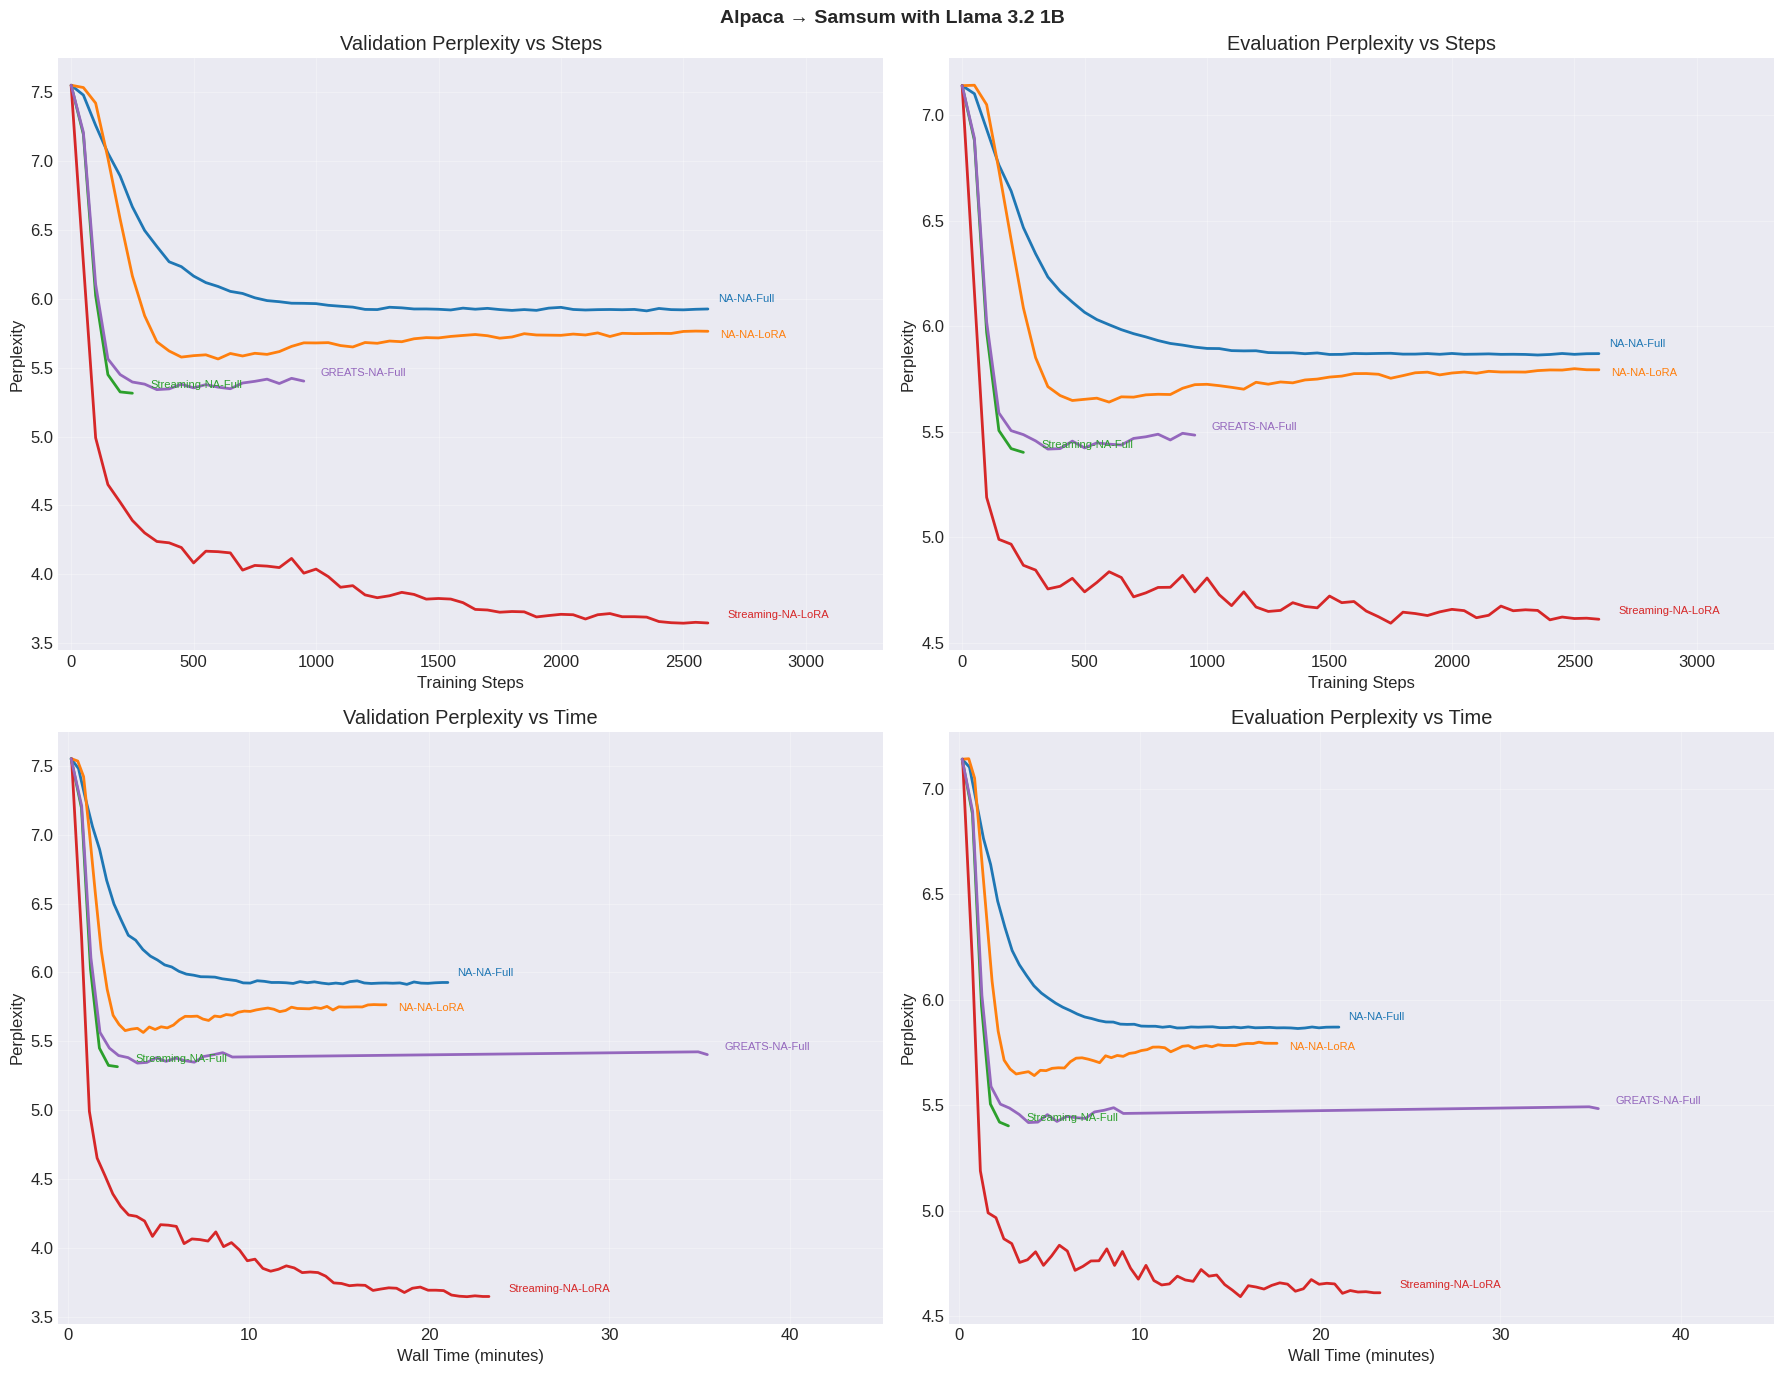

In [491]:
# Unified 2x2 plot: Training Steps (top) vs Wall Time (bottom)
# Left column: Validation Perplexity, Right column: Evaluation Perplexity

# Check if wall time data is available
has_wall_time = any(data['wall_time'] is not None for data in results.values())

# Build plot title
train_name = train_dataset.replace('_', ' ').title()
task_name = task.upper() if task in ['tydiqa', 'mmlu', 'bbh', 'gsm8k'] else task.replace('_', ' ').title()
if subject:
    task_name = f"{task_name} ({subject.replace('_', ' ').title()})"
model_name = model.replace('_', ' ').replace('-', ' ').title()
plot_title = f"{train_name} → {task_name} with {model_name}"

# Create figure: 2x2 if wall time available, 1x2 otherwise
n_rows = 2 if has_wall_time else 1
fig, axes = plt.subplots(n_rows, 2, figsize=(18, 7 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

fig.suptitle(plot_title, fontsize=14, fontweight='bold', y=0.98)

def plot_perplexity(ax, x_data, y_data, x_label, title, method_names, data_dict):
    """Helper to plot perplexity with consistent styling."""
    texts = []
    for name in method_names:
        if name not in data_dict:
            continue
        data = data_dict[name]
        x = x_data(data)
        y = y_data(data)
        if x is None:
            continue
        line, = ax.plot(x, y, linewidth=2, label=name)
        texts.append(ax.text(x[-1], y[-1], name, fontsize=8, color=line.get_color()))

    ax.set_xlabel(x_label)
    ax.set_ylabel('Perplexity')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.margins(x=0.02)
    ax.set_xlim(right=ax.get_xlim()[1] * 1.25)
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Row 1: Perplexity vs Training Steps
plot_perplexity(
    axes[0, 0],
    x_data=lambda d: d['steps'],
    y_data=lambda d: d['val_perplexity'],
    x_label='Training Steps',
    title='Validation Perplexity vs Steps',
    method_names=results.keys(),
    data_dict=results
)

plot_perplexity(
    axes[0, 1],
    x_data=lambda d: d['steps'],
    y_data=lambda d: d['eval_perplexity'],
    x_label='Training Steps',
    title='Evaluation Perplexity vs Steps',
    method_names=results.keys(),
    data_dict=results
)

# Row 2: Perplexity vs Wall Time (if available)
if has_wall_time:
    plot_perplexity(
        axes[1, 0],
        x_data=lambda d: d['wall_time'] / 60.0 if d['wall_time'] is not None else None,
        y_data=lambda d: d['val_perplexity'],
        x_label='Wall Time (minutes)',
        title='Validation Perplexity vs Time',
        method_names=results.keys(),
        data_dict=results
    )

    plot_perplexity(
        axes[1, 1],
        x_data=lambda d: d['wall_time'] / 60.0 if d['wall_time'] is not None else None,
        y_data=lambda d: d['eval_perplexity'],
        x_label='Wall Time (minutes)',
        title='Evaluation Perplexity vs Time',
        method_names=results.keys(),
        data_dict=results
    )

plt.tight_layout()
plt.show()

## Compare Final Performance

In [492]:
# Print final results
print(f"\n{'='*80}")
print(f"Final Perplexity Results: {train_dataset} → {task}")
print(f"{'='*80}")
print(f"{'Method':<35} {'Val Perplexity':<18} {'Eval Perplexity':<18}")
print("-" * 80)

# Sort by eval perplexity for easier comparison
sorted_results = sorted(results.items(), key=lambda x: x[1]['eval_perplexity'][-1])

for name, data in sorted_results:
    final_val = data['val_perplexity'][-1]
    final_eval = data['eval_perplexity'][-1]
    print(f"{name:<35} {final_val:<18.4f} {final_eval:<18.4f}")

print("=" * 80)


Final Perplexity Results: alpaca → samsum
Method                              Val Perplexity     Eval Perplexity   
--------------------------------------------------------------------------------
Streaming-NA-LoRA                   3.6460             4.6114            
Streaming-NA-Full                   5.3152             5.4019            
GREATS-NA-Full                      5.4030             5.4836            
NA-NA-LoRA                          5.7650             5.7931            
NA-NA-Full                          5.9270             5.8698            


## Task-Specific Evaluation Results

Load and display task-specific metrics:
- **SAMSum**: ROUGE-1, ROUGE-2, ROUGE-L (summarization)
- **TyDiQA**: F1 Score, Exact Match (question answering)
- **MMLU/BBH**: Accuracy (multiple choice)
- **GSM8K/MATH500**: Accuracy (math reasoning)

In [493]:
# Task-specific evaluation metrics configuration
TASK_METRICS = {
    'samsum': {
        'result_file': 'samsum_results.json',
        'metrics': ['rouge1', 'rouge2', 'rougeL'],
        'display_names': ['ROUGE-1', 'ROUGE-2', 'ROUGE-L'],
        'primary_metric': 'rougeL',
        'format': lambda x: f"{x:.3f}" if x is not None else 'N/A'
    },
    'tydiqa': {
        'result_file': 'tydiqa_results.json',
        'metrics': ['f1_score', 'exact_match'],
        'display_names': ['F1 Score', 'Exact Match'],
        'primary_metric': 'f1_score',
        'format': lambda x: f"{x:.2f}" if x is not None else 'N/A'
    },
    'mmlu': {
        'result_file': 'mmlu_results.json',
        'metrics': ['accuracy'],
        'display_names': ['Accuracy'],
        'primary_metric': 'accuracy',
        'format': lambda x: f"{x*100:.1f}%" if x is not None else 'N/A'
    },
    'bbh': {
        'result_file': 'bbh_results.json',
        'metrics': ['accuracy'],
        'display_names': ['Accuracy'],
        'primary_metric': 'accuracy',
        'format': lambda x: f"{x*100:.1f}%" if x is not None else 'N/A'
    },
    'gsm8k': {
        'result_file': 'gsm8k_results.json',
        'metrics': ['accuracy'],
        'display_names': ['Accuracy'],
        'primary_metric': 'accuracy',
        'format': lambda x: f"{x*100:.1f}%" if x is not None else 'N/A'
    },
    'math500': {
        'result_file': 'math500_results.json',
        'metrics': ['accuracy'],
        'display_names': ['Accuracy'],
        'primary_metric': 'accuracy',
        'format': lambda x: f"{x*100:.1f}%" if x is not None else 'N/A'
    }
}


def build_result_path(method_name):
    """Build path for task-specific evaluation results."""
    if method_name not in method_definitions or task not in TASK_METRICS:
        return None

    selection, compression, training_type, use_second_order = method_definitions[method_name]
    cfg = default_config

    # Build config key for LR lookup
    task_for_key = f"{task}_{subject}" if task in ['mmlu', 'bbh'] and subject else task
    config_key = f"{train_dataset}_{task_for_key}"

    # Look up LR from config file (same as build_experiment_path)
    lr = lookup_lr(method_name, config_key, training_type)

    method_str = f"{selection}-{compression}"
    if selection != 'NA' and use_second_order:
        method_str = f"{method_str}-2nd"

    task_str = f"{task}_{subject}" if task in ['mmlu', 'bbh'] and subject else task

    # Directory name (NEW ORDER: model before method_str)
    # Format: {train}_{task}-{model}-{method}-{training_type}-p{pct}-lr{lr}-b{batch}-v{n_val}-s{seed}
    dir_name = f"{train_dataset}_{task_str}-{model}-{method_str}-{training_type}-p{cfg['percentage']}-lr{lr}-b{cfg['batch_size']}-v{cfg['n_val']}-s{cfg['seed']}"

    return f"{out_dir}/{dir_name}/{TASK_METRICS[task]['result_file']}"


def load_task_results():
    """Load task-specific evaluation results for all methods."""
    task_results = {}
    for method_name in filtered_methods.keys():
        path = build_result_path(method_name)
        if path and Path(path).exists():
            with open(path, 'r') as f:
                task_results[method_name] = json.load(f)
    return task_results


# Load task-specific results
task_results = load_task_results()

if task_results and task in TASK_METRICS:
    config = TASK_METRICS[task]
    metrics = config['metrics']
    display_names = config['display_names']
    fmt = config['format']
    primary = config['primary_metric']

    # Sort by primary metric
    sorted_methods = sorted(
        task_results.items(),
        key=lambda x: x[1].get(primary, 0) or 0,
        reverse=True
    )

    # Print results table
    print(f"\n{'='*80}")
    print(f"Task-Specific Evaluation: {train_dataset} -> {task.upper()}")
    print(f"{'='*80}")

    header = f"{'Method':<30}"
    for name in display_names:
        header += f" {name:>12}"
    print(header)
    print("-" * 80)

    for method_name, data in sorted_methods:
        row = f"{method_name:<30}"
        for metric in metrics:
            value = data.get(metric)
            row += f" {fmt(value):>12}"
        print(row)

    print("=" * 80)
    print(f"Loaded {len(task_results)}/{len(filtered_methods)} evaluation results")
else:
    print(f"\nNo task-specific evaluation results found for {train_dataset} -> {task}")
    print("Run: python -m SFT.eval.eval --models_dir <path> --task", task)


No task-specific evaluation results found for alpaca -> samsum
Run: python -m SFT.eval.eval --models_dir <path> --task samsum
